# Football Analysis Modular Pipeline: Step-by-Step Processor Testing

This notebook demonstrates the modular football video analysis pipeline, testing each processor step by step with real video data and visualizing the results after each stage.

In [1]:
# Import core libraries for data handling and visualization
import cv2
import numpy as np
import matplotlib.pyplot as plt
from football_ai.domain.data_models import VideoData, FrameData
from football_ai.detection.object_detection_processor import ObjectDetectionProcessor
from football_ai.tracking.track_processor import TrackProcessor
from football_ai.motion.camera_motion_processor import CameraMotionProcessor
from football_ai.motion.object_motion_processor import ObjectMotionProcessor
from football_ai.transformation.field_transformation_processor import FieldTransformationProcessor
from football_ai.assignment.team_assignment_processor import TeamAssignmentProcessor
from football_ai.assignment.ball_assignment_processor import BallAssignmentProcessor
from football_ai.rendering.renderer_processor import RendererProcessor
import os


## Load Real Data

We will load a sample football video, extract a few frames, and prepare the data for processing through the pipeline.

In [2]:
# Path to a sample video (update if needed)
video_path = 'input_videos/08fd33_4.mp4'
assert os.path.exists(video_path), f"Video not found: {video_path}"

cap = cv2.VideoCapture(video_path)
frame_rate = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
duration = cap.get(cv2.CAP_PROP_FRAME_COUNT) / frame_rate

frames = []
for i in range(5):  # Load first 5 frames for demo
    ret, frame = cap.read()
    if not ret:
        break
    frames.append(FrameData(
        frame_number=i,
        timestamp=cap.get(cv2.CAP_PROP_POS_MSEC) / 1000.0,
        raw_frame=frame
    ))
cap.release()

video_data = VideoData(
    video_path=video_path,
    frame_rate=frame_rate,
    resolution=(width, height),
    duration=duration,
    frames=frames
)

print(f"Loaded {len(frames)} frames from {video_path}")

Loaded 5 frames from input_videos/08fd33_4.mp4


## Define Pipeline Processors

We will use the following modular processors:
- **ObjectDetectionProcessor**: Detects players, ball, and other objects in each frame.
- **TrackProcessor**: Assigns consistent IDs to detected objects across frames.
- **CameraMotionProcessor**: Estimates camera movement between frames.
- **ObjectMotionProcessor**: Computes object motion (e.g., speed, direction).
- **SimpleFieldTransformationProcessor**: Maps pixel coordinates to field coordinates.
- **TeamAssignmentProcessor**: Assigns detected players to teams.
- **BallAssignmentProcessor**: Assigns the ball to the nearest player/goalkeeper.
- **RendererProcessor**: Renders all results visually on the video frames.

In [3]:
# Initialize processors (update model paths as needed)
model_paths = {
    'detection': 'models/detect/best.pt',
}




## Visualize Results After Each Processor

After each processor, we will visualize the results for the first frame to observe the changes and outputs at each stage.

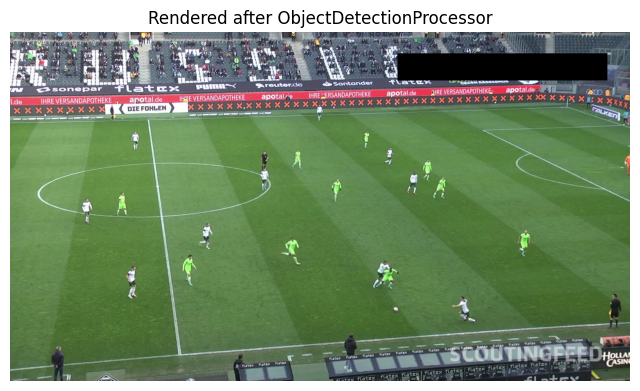

In [4]:
# 1. Object Detection
object_detection = ObjectDetectionProcessor(model_paths['detection'])
video_data_det = object_detection.process(video_data)
renderer = RendererProcessor(output_path="outputs/videos/demo_output.mp4")
rendered_det = renderer.process(video_data_det)
frame_det = rendered_det.frames[0].raw_frame
plt.figure(figsize=(8, 5))
plt.imshow(cv2.cvtColor(frame_det, cv2.COLOR_BGR2RGB))
plt.title("Rendered after ObjectDetectionProcessor")
plt.axis('off')
plt.show()




In [ ]:


# 2. Tracking
track_processor = TrackProcessor()
video_data_track = track_processor.process(video_data_det)
rendered_track = renderer.process(video_data_track)
frame_track = rendered_track.frames[0].raw_frame
plt.figure(figsize=(8, 5))
plt.imshow(cv2.cvtColor(frame_track, cv2.COLOR_BGR2RGB))
plt.title("Rendered after TrackProcessor")
plt.axis('off')
plt.show()

# 3. Camera Motion
camera_motion = CameraMotionProcessor()
video_data_cam = camera_motion.process(video_data_track)
rendered_cam = renderer.process(video_data_cam)
frame_cam = rendered_cam.frames[0].raw_frame
plt.figure(figsize=(8, 5))
plt.imshow(cv2.cvtColor(frame_cam, cv2.COLOR_BGR2RGB))
plt.title("Rendered after CameraMotionProcessor")
plt.axis('off')
plt.show()

# 4. Object Motion
object_motion = ObjectMotionProcessor()
video_data_obj = object_motion.process(video_data_cam)
rendered_obj = renderer.process(video_data_obj)
frame_obj = rendered_obj.frames[0].raw_frame
plt.figure(figsize=(8, 5))
plt.imshow(cv2.cvtColor(frame_obj, cv2.COLOR_BGR2RGB))
plt.title("Rendered after ObjectMotionProcessor")
plt.axis('off')
plt.show()

# 5. Field Transformation
field_transform = FieldTransformationProcessor()
video_data_field = field_transform.process(video_data_obj)
rendered_field = renderer.process(video_data_field)
frame_field = rendered_field.frames[0].raw_frame
plt.figure(figsize=(8, 5))
plt.imshow(cv2.cvtColor(frame_field, cv2.COLOR_BGR2RGB))
plt.title("Rendered after FieldTransformationProcessor")
plt.axis('off')
plt.show()

# 6. Team Assignment
team_assign = TeamAssignmentProcessor()
video_data_team = team_assign.process(video_data_field)
rendered_team = renderer.process(video_data_team)
frame_team = rendered_team.frames[0].raw_frame
plt.figure(figsize=(8, 5))
plt.imshow(cv2.cvtColor(frame_team, cv2.COLOR_BGR2RGB))
plt.title("Rendered after TeamAssignmentProcessor")
plt.axis('off')
plt.show()

# 7. Ball Assignment
ball_assign = BallAssignmentProcessor()
video_data_ball = ball_assign.process(video_data_team)
rendered_ball = renderer.process(video_data_ball)
frame_ball = rendered_ball.frames[0].raw_frame
plt.figure(figsize=(8, 5))
plt.imshow(cv2.cvtColor(frame_ball, cv2.COLOR_BGR2RGB))
plt.title("Rendered after BallAssignmentProcessor")
plt.axis('off')
plt.show()
